# Customer Segmentation — Exploratory Data Analysis
## Data Mining & Machine Learning | February 2026
**Team:** Muhammad Junaid Minhas (23L-2559) & Safee Akmal (23L-2556)

**Sprint:** 1 | **User Stories:** US-2.1, US-2.2, US-2.3

---

### Notebook Objectives
1. Load and inspect the raw Customer Personality Analysis dataset
2. Perform univariate and bivariate EDA across all 29 features
3. Detect missing values, outliers, and data quality issues
4. Document findings that drive Sprint 2 preprocessing decisions

> **Read before running:** This notebook is read-only EDA — no data is modified here.
> All cleaning decisions are implemented in `02_Preprocessing.ipynb` and `data_processing.py`.

## Section 1 — Load & Inspect

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

In [26]:
# US-2.1 — Load dataset
# Tab-separated, latin-1 encoded — both parameters are required
DATA_PATH = '../data/raw/marketing_campaign.csv'

df = pd.read_csv(DATA_PATH, sep='\t', parse_dates=[' Dt_Customer'],
                 dayfirst=True, encoding='latin-1')

# Strip leading/trailing spaces from column names
df.columns = df.columns.str.strip()

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head(15)

Shape: (2240, 29)
Rows: 2,240 | Columns: 29


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513,0,1,2013-09-09,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635,0,1,2012-11-13,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454,1,0,2013-05-08,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351,1,0,2013-06-06,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648,1,1,2014-03-13,68,28,...,20,1,0,0,0,0,0,3,11,0


In [6]:
# Column dtypes overview
df.dtypes.to_frame('dtype').T

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
dtype,int64,int64,object,object,object,int64,int64,datetime64[ns],int64,int64,...,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64


In [28]:
df['Income'] = df['Income'].astype(str).str.replace(r'[$, ]', '', regex=True)

# 2. Convert to numeric, forcing errors to NaN
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

In [29]:
# Full info summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

### 1.1 Missing Values

In [30]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing)
print(f'\nTotal missing: {missing.sum()} / {df.shape[0] * df.shape[1]:,} cells')
print(f'Income null rate: {df["Income"].isnull().mean():.2%}')

Columns with missing values:
Income    24
dtype: int64

Total missing: 24 / 64,960 cells
Income null rate: 1.07%


> **Finding:** Only `Income` has missing values — 24 rows (~1.07%).
> **Decision:** Median imputation in the preprocessing pipeline.
> Mean is rejected because Income is right-skewed.

In [16]:
# Duplicate check
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

Duplicate rows: 0


### 1.2 Date Range of Customer Enrolment

Earliest enrolment : 2012-07-30
Latest enrolment   : 2014-06-29
Enrolment span     : 699 days


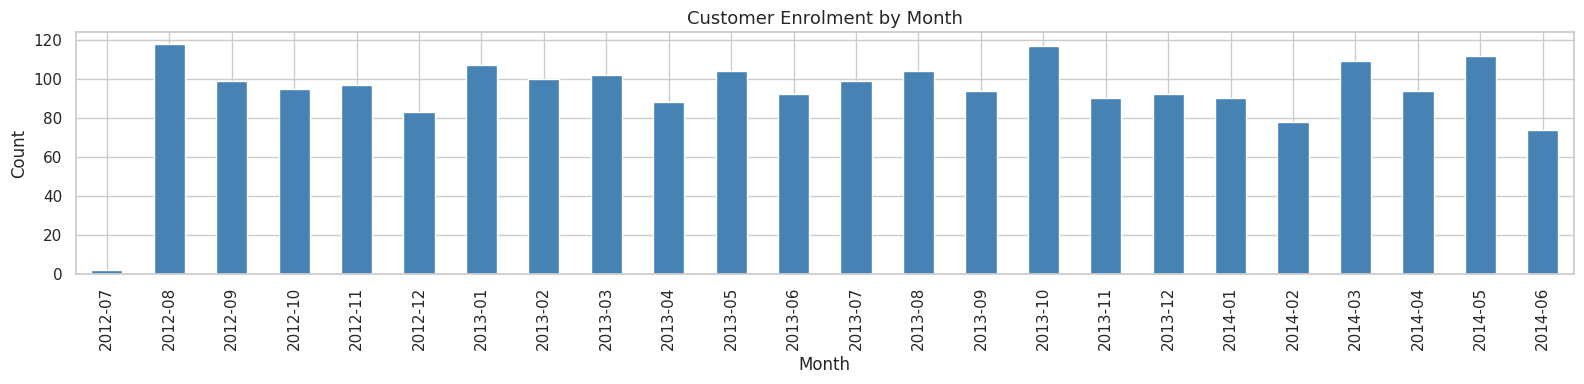

In [17]:
print(f'Earliest enrolment : {df["Dt_Customer"].min().date()}')
print(f'Latest enrolment   : {df["Dt_Customer"].max().date()}')
print(f'Enrolment span     : {(df["Dt_Customer"].max() - df["Dt_Customer"].min()).days} days')

df['Dt_Customer'].dt.to_period('M').value_counts().sort_index().plot(
    kind='bar', figsize=(16, 4), color='steelblue', edgecolor='white')
plt.title('Customer Enrolment by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../figures/enrolment_trend.png', dpi=150)
plt.show()

## Section 2 — Univariate Analysis

### 2.1 Numeric Features — Distributions

In [18]:
numeric_cols = ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
                'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
                'MntSweetProducts', 'MntGoldProds',
                'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                'NumStorePurchases', 'NumWebVisitsMonth']

df[numeric_cols].describe().round(2)

,Year_Birth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00
mean,1968.81,0.44,0.51,49.11,303.94,26.30,166.95,37.53,27.06,44.02,2.33,4.08,2.66,5.79,5.32
std,11.98,0.54,0.54,28.96,336.60,39.77,225.72,54.63,41.28,52.17,1.93,2.78,2.92,3.25,2.43
min,1893.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1959.00,0.00,0.00,24.00,23.75,1.00,16.00,3.00,1.00,9.00,1.00,2.00,0.00,3.00,3.00
50%,1970.00,0.00,0.00,49.00,173.50,8.00,67.00,12.00,8.00,24.00,2.00,4.00,2.00,5.00,6.00
75%,1977.00,1.00,1.00,74.00,504.25,33.00,232.00,50.00,33.00,56.00,3.00,6.00,4.00,8.00,7.00
max,1996.00,2.00,2.00,99.00,1493.00,199.00,1725.00,259.00,263.00,362.00,15.00,27.00,28.00,13.00,20.00


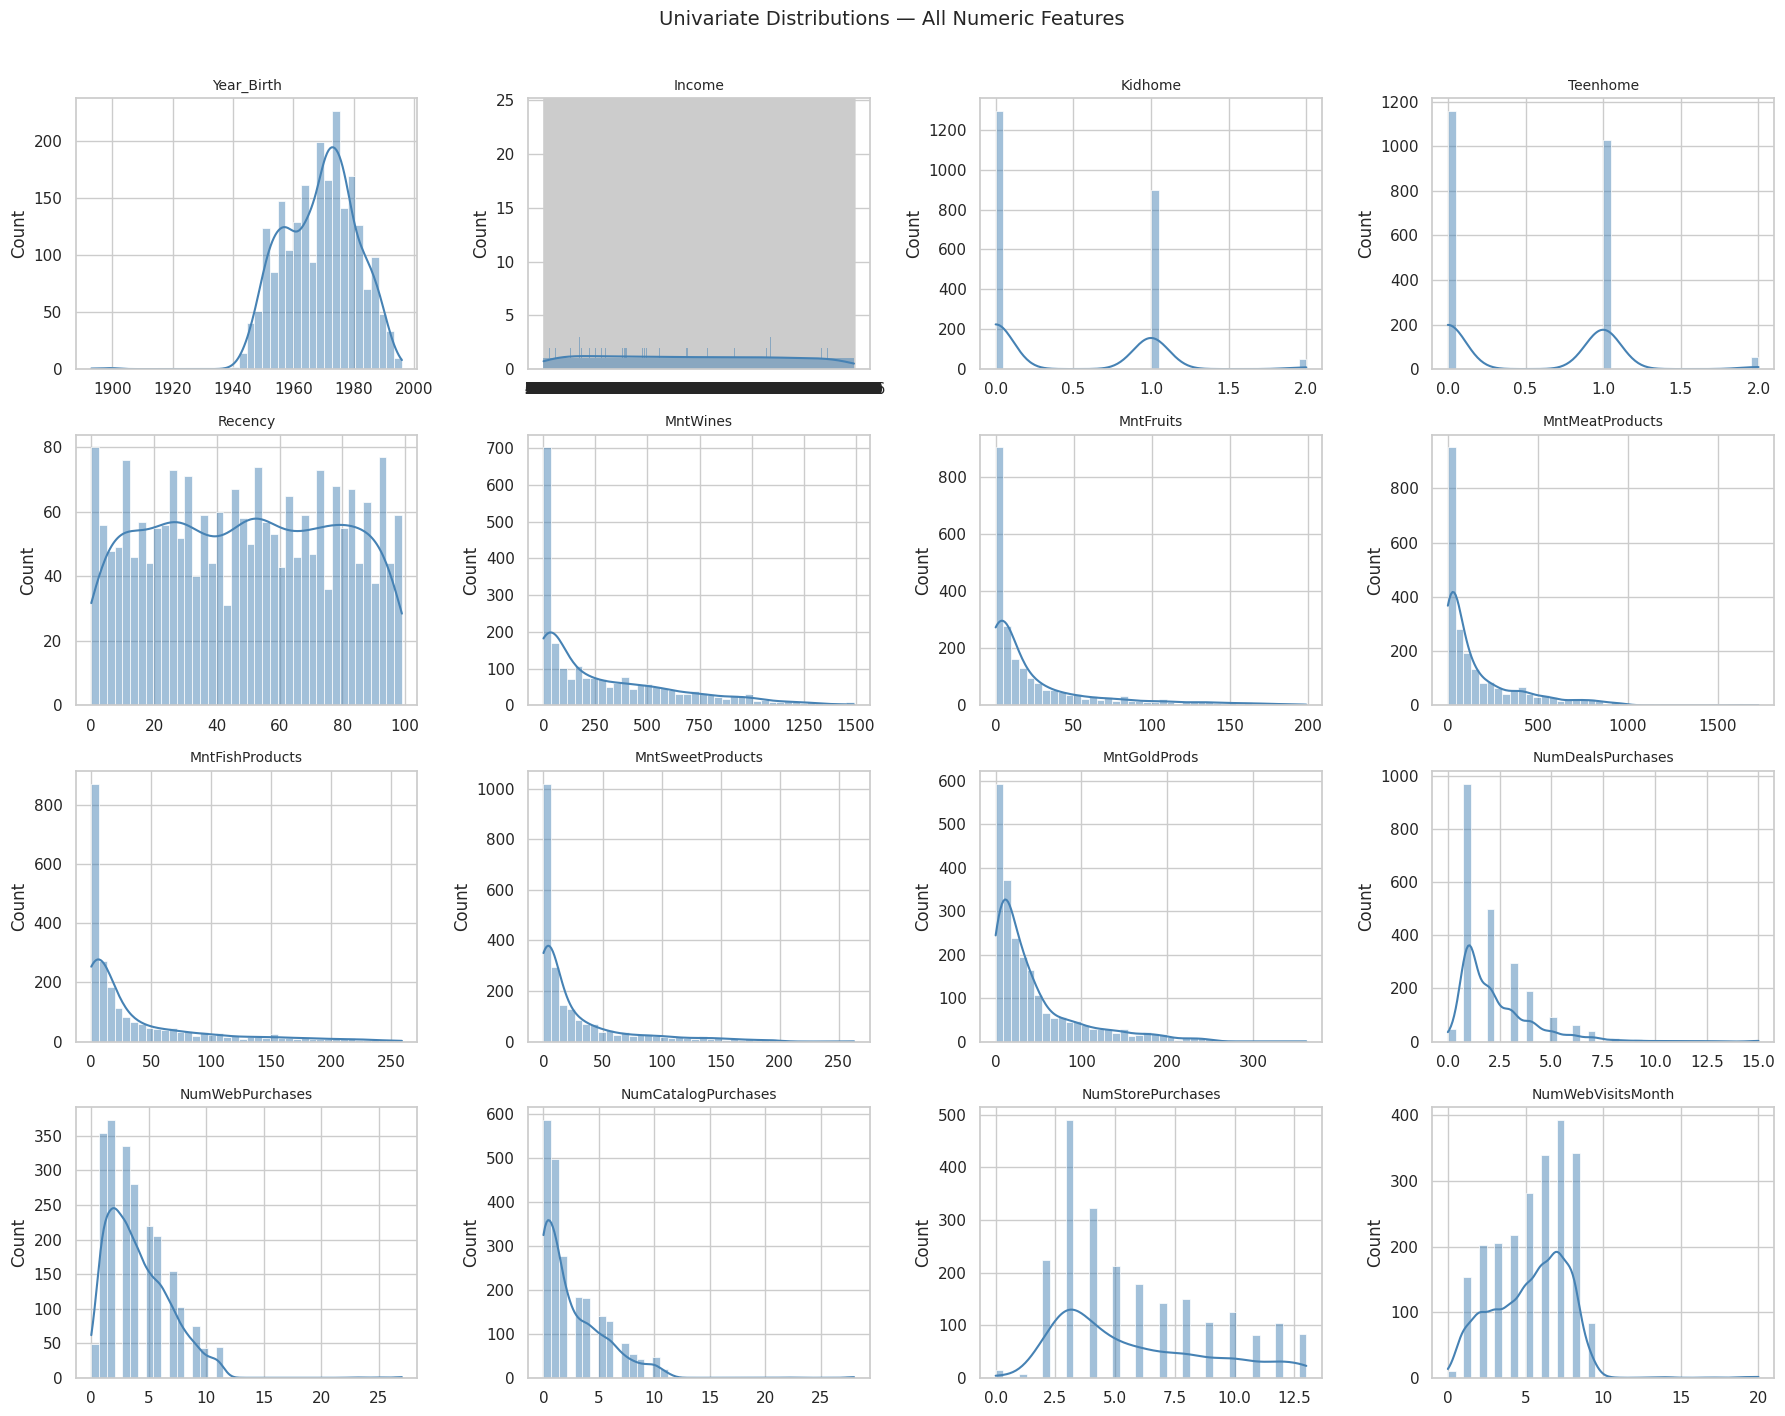

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), ax=axes[i], kde=True, color='steelblue', bins=40)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Univariate Distributions — All Numeric Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

> **Key findings:**
> - `Income`: right-skewed, one extreme outlier at ~666,666 → will be dropped
> - `MntWines`: highest spend category, wide range 0–1493
> - All `Mnt*` columns: heavily right-skewed, most customers near zero
> - `Recency`: uniformly distributed 0–99 — will not dominate clustering
> - `Year_Birth`: three implausible values (1893–1900) → clip Age to 18–90

### 2.2 Categorical Features — Value Counts

In [ ]:
cat_cols = ['Education', 'Marital_Status']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=axes[i], palette='Blues_r')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Count')
    for j, v in enumerate(vc.values):
        axes[i].text(v + 5, j, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/categorical_distributions.png', dpi=150)
plt.show()

In [ ]:
# Identify dirty Marital_Status values
print('All Marital_Status values:')
print(df['Marital_Status'].value_counts())
print()
dirty = df[df['Marital_Status'].isin(['Absurd', 'YOLO', 'Alone'])]
print(f'Rows with dirty Marital_Status: {len(dirty)}')

> **Finding:** 7 rows have invalid Marital_Status values (Absurd=2, YOLO=2, Alone=3).
> **Decision:** Drop these rows in `engineer_features()` — they would create spurious
> one-hot columns with no predictive signal.

## Section 3 — Outlier Detection

In [ ]:
# Income outlier — boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['Income'].dropna(), ax=axes[0], color='steelblue')
axes[0].set_title('Income — With Outlier')

sns.boxplot(y=df[df['Income'] < 200_000]['Income'].dropna(), ax=axes[1], color='seagreen')
axes[1].set_title('Income — Outlier Removed (< 200k)')

plt.tight_layout()
plt.savefig('../figures/income_outlier.png', dpi=150)
plt.show()

print('Extreme Income values (> 200,000):')
print(df[df['Income'] > 200_000][['Income', 'Education', 'Marital_Status']])

In [ ]:
# Spend columns — box plots
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

fig, axes = plt.subplots(1, 6, figsize=(18, 5))
for i, col in enumerate(spend_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col.replace('Mnt', ''), fontsize=9)

plt.suptitle('Spend Columns — Outlier Detection', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/spend_boxplots.png', dpi=150)
plt.show()

## Section 4 — Bivariate Analysis

In [ ]:
# Quick feature engineering for bivariate analysis only (not saved)
df_biv = df.copy()
df_biv['TotalSpent'] = df_biv[spend_cols].sum(axis=1)
df_biv['Age'] = pd.Timestamp.now().year - df_biv['Year_Birth']
df_biv = df_biv[df_biv['Income'] < 600_000].dropna(subset=['Income'])

# Income vs TotalSpent
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_biv, x='Income', y='TotalSpent', alpha=0.4, color='steelblue')
sns.regplot(data=df_biv, x='Income', y='TotalSpent', scatter=False, color='red', line_kws={'lw':1.5})
plt.title('Income vs TotalSpent  (r ≈ {:.2f})'.format(df_biv[['Income','TotalSpent']].corr().iloc[0,1]))
plt.tight_layout()
plt.savefig('../figures/income_vs_spend.png', dpi=150)
plt.show()

In [ ]:
# Age vs TotalSpent by Education
plt.figure(figsize=(11, 5))
sns.scatterplot(data=df_biv, x='Age', y='TotalSpent',
                hue='Education', alpha=0.5, palette='tab10')
plt.title('Age vs TotalSpent  (coloured by Education)')
plt.tight_layout()
plt.savefig('../figures/age_vs_spend.png', dpi=150)
plt.show()

In [ ]:
# Correlation heatmap — numeric features
numeric_for_corr = ['Income', 'Age', 'Recency', 'TotalSpent',
                    'NumWebPurchases', 'NumCatalogPurchases',
                    'NumStorePurchases', 'NumDealsPurchases', 'NumWebVisitsMonth',
                    'Kidhome', 'Teenhome'] + spend_cols

corr = df_biv[numeric_for_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, annot_kws={'size': 7}, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../figures/correlation_heatmap.png', dpi=150)
plt.show()

## Section 5 — Campaign Response Analysis

In [ ]:
# Response rate overall
print(f'Overall campaign acceptance rate: {df["Response"].mean():.2%}')
print()

# Response by Education
print('Acceptance rate by Education:')
print(df.groupby('Education')['Response'].mean().sort_values(ascending=False).round(4))
print()

# Response by Marital Status (clean values only)
clean = df[~df['Marital_Status'].isin(['Absurd', 'YOLO', 'Alone'])]
print('Acceptance rate by Marital Status:')
print(clean.groupby('Marital_Status')['Response'].mean().sort_values(ascending=False).round(4))

> **Critical decision:** `Response` is **NOT** included as a clustering feature.
> Using it as input would make segmentation partially supervised — grouping
> customers by their known campaign outcome rather than discovering natural
> behavioural personalities. It is reserved as a **post-hoc validation metric**
> only (used in `04_Evaluation.ipynb` after clustering).

## Section 6 — Key Observations & Decisions for Sprint 2

### Summary Table

| Finding | Decision | Implemented In |
|---|---|---|
| File is tab-separated, latin-1 encoded | `sep='\t', encoding='latin-1'` | `load_data()` |
| `Dt_Customer` is a date | `parse_dates=['Dt_Customer']` | `load_data()` |
| `Income`: 24 nulls, right-skewed | Median imputation | `build_preprocessing_pipeline()` |
| Income outlier at 666,666 | Drop rows where Income > 600,000 | `engineer_features()` |
| Marital_Status: Absurd, YOLO, Alone | Drop 7 rows | `engineer_features()` |
| Year_Birth implausible values | Clip Age to 18–90 | `engineer_features()` |
| Mnt* columns all right-skewed | Aggregate into `TotalSpent` | `engineer_features()` |
| Channel counts conflate volume+preference | Engineer channel share ratios | `engineer_features()` |
| Features on vastly different scales | `StandardScaler` | `build_preprocessing_pipeline()` |
| `Response` is a post-hoc metric | Excluded from feature list | `build_preprocessing_pipeline()` |